# Part A: Probabilistic Gaussian Generative Classifier

### A1. Dataset and Setup

In [28]:
# imports and dataset loading + stratified 70/15/15 split
import numpy as np
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X = digits.data
y = digits.target

# First split: train 70%, temp 30%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42  # the argument stratify=y is used to ensure each subset has the same proportion of classes (digits 0–9) as the original dataset.
)
# Second split: temp -> val 15% and test 15% (split temp half-half)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# standardize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_val_std = scaler.transform(X_val)
X_test_std = scaler.transform(X_test)


### A2. Gaussian Generative Model

In [29]:
# Gaussian Generative Classifier implementation (shared covariance)
import numpy as np

class GaussianGenerativeClassifier:
    def __init__(self, reg_lambda=1e-3):
        self.reg_lambda = reg_lambda # Regularization strength λ
        self.classes_ = None # List of class labels
        self.pi_ = None # πk​=P(y=k)
        self.mu_ = None # The mean vector of each class
        self.Sigma_ = None # The shared covariance matrix Σ (64×64)
        self.Sigma_inv_ = None # The inverse of the covariance matrix, Σ⁻¹
        self.log_det_Sigma_ = None # log∣Σ∣
        self.d_ = None # The number of features, d which is 64

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        n, d = X.shape # Extract number of samples n and dimension d
        self.d_ = d
        classes = np.arange(10) # array from 0 to 9
        K = classes.size
        self.classes_ = classes

        # Estimate priors and means
        pi = np.zeros(K, dtype=float) # Creates a vector of length K (10) filled with zeros
        mu = np.zeros((K, d), dtype=float) # Creates a 2D array of shape (10, 64)
        for k in classes: 
            Xk = X[y == k] # contains all images of digit k
            pi[k] = Xk.shape[0] / n # number of samples in class k divided by total number of samples
            mu[k] = Xk.mean(axis=0) # a 64-dimensional mean vector for class k
        self.mu_ = mu
        self.pi_ = pi

        # Estimate shared covariance: Σ = (1/n) Σᵢ (xᵢ – μᵧᵢ)(xᵢ – μᵧᵢ)ᵀ
        Sigma = np.zeros((d, d), dtype=float) # 64 × 64 matrix filled with zeros
        for i in range(n):
            k = y[i]
            diff = (X[i] - mu[k]).reshape(d, 1)
            Sigma += diff @ diff.T
        Sigma /= n
        self.Sigma_ = Sigma


        # Regularize covariance: Σ_λ = Σ + λI
        Sigma += self.reg_lambda * np.eye(d) # to ensure sigma is positive definite, invertible and numerically stable

        # precompute inverse (Σ⁻¹) and log-det (log(|Σ|))
        Sigma_inv = np.linalg.inv(Sigma)
        logdet = np.linalg.slogdet(Sigma)[1]
        self.Sigma_inv_ = Sigma_inv
        self.log_det_Sigma_ = logdet
       

    def _log_gaussian(self, x, mu_k): #compute log N(x ∣ μk​,Σ)
        diff = x - mu_k
        quad = -0.5 * diff @ (self.Sigma_inv_ @ diff.T)
        const = -0.5 * (self.d_ * np.log(2 * np.pi) + self.log_det_Sigma_)
        return quad + const

    def predict(self, X):
        n = X.shape[0]
        K = self.classes_.size
        scores = np.zeros((n, K))
        for i in range(K):
            log_prior = np.log(self.pi_[i] + 1e-12) # cmpute logπi and we add e-12 to avoid log(0)
            mu_i = self.mu_[i]
            for j in range(n):
                scores[j, i] = log_prior + float(self._log_gaussian(X[j], mu_i)) # log p(y=i ∣ X[j]) = log p(y=i) + log p(X[j] ∣ y=i)
        pred_idx = scores.argmax(axis=1) # finds the predicted class index of the maximum score for each row ; axis=1 means look row by row (for each sample)
        predicted_labels= self.classes_[pred_idx] # converts indices back to actual class labels
        return predicted_labels, scores


### A3. Hyperparameter Tuning and Evaluation

In [30]:
# hyperparameter tuning for lambda
from sklearn.metrics import accuracy_score
import pandas as pd

lambdas = [1e-4, 1e-3, 1e-2, 1e-1]
val_results = [] # will store for each lamda value (λ, validation accuracy)
for lam in lambdas:
    clf = GaussianGenerativeClassifier(reg_lambda=lam)
    clf.fit(X_train_std, y_train) # Estimates π, μ, Σ using X_train_std and y_train
    y_val_pred, _ = clf.predict(X_val_std)
    acc = accuracy_score(y_val, y_val_pred)
    val_results.append((lam, acc))
df_val = pd.DataFrame(val_results, columns=["lambda", "val_accuracy"])
df_val_sorted = df_val.sort_values("val_accuracy", ascending=False)
best_row = df_val.sort_values(["val_accuracy", "lambda"], ascending=[False, True]).iloc[0] # First sort by validation accuracy (higher accuracy first) then choose smaller λ preferred if tie
best_lambda = float(best_row["lambda"])

# retrain on train+val with best lambda, evaluate on test
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

X_combined = np.vstack([X_train_std, X_val_std])
y_combined = np.concatenate([y_train, y_val])

final_clf = GaussianGenerativeClassifier(reg_lambda=best_lambda)
final_clf.fit(X_combined, y_combined)
y_test_pred, scores_test = final_clf.predict(X_test_std)

test_acc = accuracy_score(y_test, y_test_pred)
macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='macro', zero_division=0) # average='macro' → treats all classes equally and zero_division=0 → avoids errors if a class has no predictions
conf_mat = confusion_matrix(y_test, y_test_pred)
metrics = {
    "Metric": ["Test Accuracy", "Macro Precision", "Macro Recall", "Macro F1-score"],
    "Value": [test_acc, macro_prec, macro_rec, macro_f1]
}



### A4. Report

,lambda,val_accuracy
0,0.000100,0.9444
1,0.001000,0.9444
2,0.010000,0.9444
3,0.100000,0.9444


Best lambda chosen: 0.0001


Classification Metrics:


,Metric,Value
0,Test Accuracy,0.9630
1,Macro Precision,0.9632
2,Macro Recall,0.9627
3,Macro F1-score,0.9625


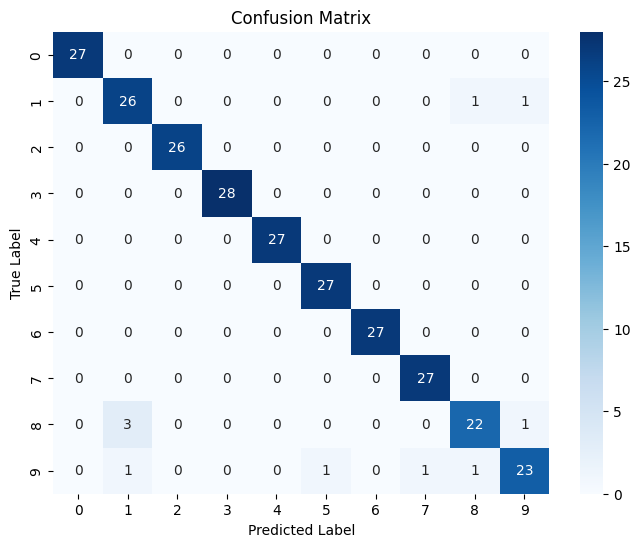

In [31]:
# Table for lambda vs validation accuracy
display(df_val_sorted.style.format({"val_accuracy": "{:.4f}"}).set_caption("Validation Accuracy vs Lambda"))
print("Best lambda chosen:", best_lambda)

# Create table
metrics_df = pd.DataFrame(metrics)
print("\n\nClassification Metrics:")
display(metrics_df.style.format({"Value": "{:.4f}"}).set_caption("Performance Metrics"))

# Create confusion matrix
conf_df = pd.DataFrame(conf_mat, index=range(10), columns=range(10))
plt.figure(figsize=(8,6))
sns.heatmap(conf_df, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


Top Confused Digit Pairs:
- 8 predicted as 1: 3 times
- 9 predicted as 8: 1 times
- 9 predicted as 7: 1 times
- 9 predicted as 5: 1 times
- 9 predicted as 1: 1 times



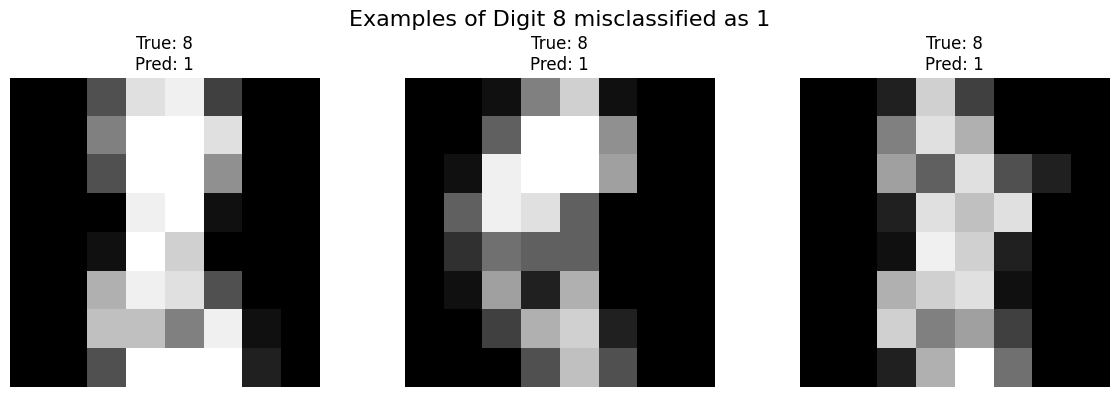

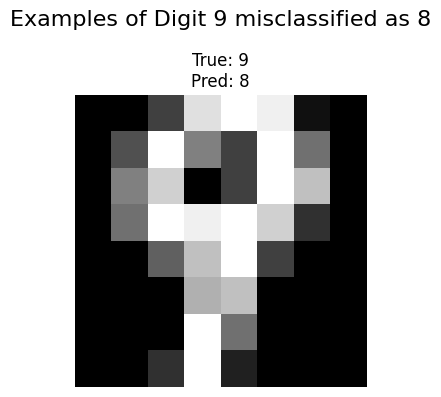

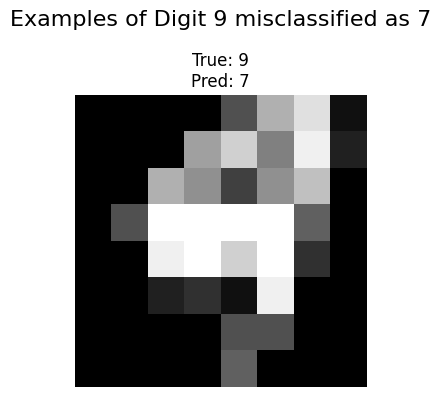

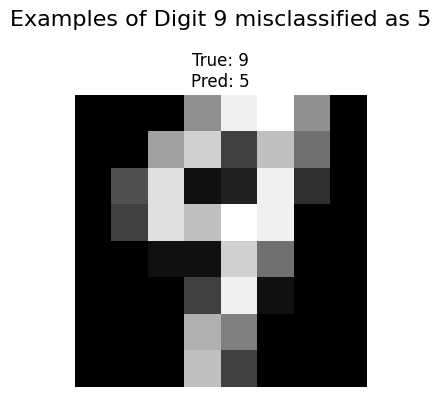

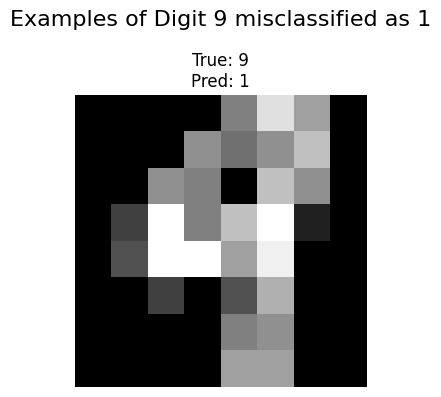

In [32]:
# --- Identify Top Confusions ---
import numpy as np

# Zero out the diagonal (correct predictions) to focus only on misclassifications
cm_no_diag = conf_mat.copy().astype(int)
np.fill_diagonal(cm_no_diag, 0)

# Collect all misclassifications as tuples: (count, true_label, predicted_label)
confusions = []
for i in range(cm_no_diag.shape[0]):
    for j in range(cm_no_diag.shape[1]):
        if cm_no_diag[i, j] > 0:
            confusions.append((cm_no_diag[i, j], i, j))

# Sort by highest count first
confusions_sorted = sorted(confusions, reverse=True)

# Take top 5 most confused digit pairs
top_confusions = confusions_sorted[:5]



# --- Update report text with top confusions ---
top_confusion_text = "Top Confused Digit Pairs:\n"
for count, true_label, pred_label in top_confusions:
    top_confusion_text += f"- {true_label} predicted as {pred_label}: {count} times\n"

print(top_confusion_text)

import matplotlib.pyplot as plt
import numpy as np

# --- Identify misclassified samples ---
misclassified_idx = np.where(y_test != y_test_pred)[0]

# Function to enlarge 8x8 image to 32x32
def enlarge_image(img, factor=4):
    return np.kron(img, np.ones((factor, factor)))  # repeats each pixel in a factor x factor block

# Plotting top 5 confused pairs 
for count, true_label, pred_label in top_confusions:
    # Find indices for this confused pair
    pair_idx = [i for i in misclassified_idx if y_test[i]==true_label and y_test_pred[i]==pred_label]
    
    if len(pair_idx) == 0:
        continue  # skip if no examples
    
    num_examples = min(len(pair_idx), 3)
    plt.figure(figsize=(num_examples*4, 4))
    
    for j, idx in enumerate(pair_idx[:num_examples]):
        plt.subplot(1, num_examples, j+1)
        img_enlarged = enlarge_image(X_test[idx].reshape(8,8), factor=4)
        plt.imshow(img_enlarged, cmap='gray', interpolation='nearest')
        plt.title(f"True: {y_test[idx]}\nPred: {y_test_pred[idx]}", fontsize=12)
        plt.axis('off')
    
    plt.suptitle(f"Examples of Digit {true_label} misclassified as {pred_label}", fontsize=16)
    plt.tight_layout()
    plt.show()


### Short Explanation of the Model

The Gaussian generative classifier is a **probabilistic model** that assumes the following:

- **Class prior:** \(p(y=k) = pi_k\), estimated as the fraction of training samples belonging to class \(k\).

- **Class-conditional distribution:** \(p(x mid y=k)\) is modeled as a **multivariate Gaussian** with mean vector \(mu_k\) and a **shared covariance matrix** \(Sigma\) for all classes.

The **parameters are estimated from the training data** as follows:

- **πₖ:** Count the number of samples in class \(k\) and divide by the total number of samples.

- **μₖ:** Compute the average (mean vector) of all training samples belonging to class \(k\).

- **Σ:** Compute the shared covariance using all samples, summing \((x_i - mu_{y_i})(x_i - mu_{y_i})^T\) over all training points, then divide by the total number of samples.

To ensure numerical stability and invertibility of the covariance matrix, we **regularize** it by adding a small value \(lambda) to the diagonal:

\[
Sigma_lambda = Sigma + lambda I
\]

- **Small λ:** May lead to an ill-conditioned covariance and unstable predictions.
- **Large λ:** Over-smooths the covariance and may reduce model performance.

---

### Short Discussion

The classifier performs well overall, but certain digits are confused due to visual similarity. For example, in our results the top 5 confused digits:
- **8** predicted as **1**: **3 times**
- **9** predicted as **8**: **1 times**
- **9** predicted as **7**: **1 times**
- **9** predicted as **5**: **1 times**
- **9** predicted as **1**: **1 times**

The choice of \(lambda\) slightly affects performance. Very small values can cause instability in the covariance inversion, while very large values can slightly reduce accuracy because the covariance becomes too “smooth.” Overall, the Gaussian generative model is **effective for classifying handwritten digits** and achieves high accuracy, but it has limitations when distinguishing visually similar digits. Its main strengths are simplicity and solid performance on well-separated classes, while its weakness is handling subtle differences between similar digits.


#### Probabilistic Gaussian Generative Classifier — Full Mathematical Formulation

##### Class Prior
$$
p(y = k) = \pi_k
$$

##### Class-Conditional Likelihood
$$
p(x \mid y=k) = \mathcal{N}(x ; \mu_k, \Sigma)
$$

##### Prior Estimate
$$
\hat{\pi}_k = \frac{1}{n} \sum_{i=1}^{n} \mathbf{1}(y_i = k)
$$

##### Mean Estimate
$$
\hat{\mu}_k = \frac{1}{n_k} \sum_{i: y_i = k} x_i
$$

##### Shared Covariance Estimate
$$
\hat{\Sigma}
= \frac{1}{n}
\sum_{i=1}^{n}
(x_i - \hat{\mu}_{y_i})(x_i - \hat{\mu}_{y_i})^T
$$

##### Regularized Covariance
$$
\Sigma_{\lambda} = \hat{\Sigma} + \lambda I
$$

##### Log Posterior Score
$$
\log p(y=k \mid x)
\propto
\log \pi_k
-\frac{1}{2}(x - \mu_k)^T \Sigma_\lambda^{-1} (x - \mu_k)
-\frac{1}{2}\log|\Sigma_\lambda|
$$

##### Prediction Rule
$$
\hat{y} = \arg\max_{k}
\left[
\log \pi_k + \log \mathcal{N}(x ; \mu_k, \Sigma_\lambda)
\right]
$$


# Part B: Naïve Bayes

In [2]:
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Load dataset
data = fetch_openml("adult", version=2, as_frame=True)
df = data.frame.copy()
df_original = data.frame.copy()
print(df.shape)


# Keep only categorical columns + target
categorical_features = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country"
]

target = "class"

df = df[categorical_features + [target]]
df_original = df_original[categorical_features + [target]]

# Replace "?" with "Missing"
df = df.replace("?", "Missing")
df_original = df_original.replace("?", "Missing")

# FIX NaN for categorical columns
for col in categorical_features:
    df[col] = df[col].cat.add_categories("Missing")
    df[col] = df[col].fillna("Missing")

#print(df.head(5)) 

# Encode categories as numbers
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
df[categorical_features] = encoder.fit_transform(df[categorical_features])

# Convert target to 0/1
df[target] = df[target].apply(lambda x: 1 if x == ">50K" else 0)

# Prepare data
X = df[categorical_features].values
y = df[target].values

# Split 70% train
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Split 30% → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

df.head(5)


(48842, 15)
Train: (34189, 8)
Val: (7326, 8)
Test: (7327, 8)


,workclass,education,marital-status,occupation,relationship,race,sex,native-country,class
0,4.0,1.0,4.0,6.0,3.0,2.0,1.0,39.0,0
1,4.0,11.0,2.0,4.0,0.0,4.0,1.0,39.0,0
2,1.0,7.0,2.0,11.0,0.0,4.0,1.0,39.0,1
3,4.0,15.0,2.0,6.0,0.0,2.0,1.0,39.0,1
4,2.0,15.0,4.0,7.0,3.0,4.0,0.0,39.0,0


#### ================================
##### PART B1: DATA ANALYSIS SECTION
#### ================================


In [3]:
# 1. CLASS DISTRIBUTION

print("=== Class Distribution (Counts) ===")
print(df[target].value_counts())
print("\n=== Class Distribution (Percentages) ===")
print(df[target].value_counts(normalize=True)*100)


=== Class Distribution (Counts) ===
class
0    37155
1    11687
Name: count, dtype: int64

=== Class Distribution (Percentages) ===
class
0    76.071823
1    23.928177
Name: proportion, dtype: float64


### Class Distribution Analysis

- The Adult Income dataset is imbalanced.
Out of 48,842 samples:

- 37,155 (76.07%) belong to the ≤50K class

- 11,687 (23.93%) belong to the >50K class

- This means the majority class dominates the dataset.
- As a result:

- - Models may become biased toward predicting ≤50K

- - Accuracy alone is not a reliable metric

- - We need to report precision, recall, and F1-score, especially for the minority class (>50K)

In [27]:
# 2. FEATURE–TARGET RELATIONSHIPS

print("\n=== Workclass vs Income (Original Categories) ===")
print(pd.crosstab(df_original["workclass"], df_original[target], normalize="index")) #crosstab counts: For each category how many people earn ≤50K and how many earn >50K  
                                                                                     #normalize="index" = converts each row into percentages.
                                                                                     
print("\n=== Education vs Income (Original Categories) ===")
print(pd.crosstab(df_original["education"], df_original[target], normalize="index"))

print("\n=== Marital-status vs Income (Original Categories) ===")
print(pd.crosstab(df_original["marital-status"], df_original[target], normalize="index"))

print("\n=== Occupation vs Income (Original Categories) ===")
print(pd.crosstab(df_original["occupation"], df_original[target], normalize="index"))

print("\n=== Relationship vs Income (Original Categories) ===")
print(pd.crosstab(df_original["relationship"], df_original[target], normalize="index"))



=== Workclass vs Income (Original Categories) ===
class                <=50K      >50K
workclass                           
Federal-gov       0.608240  0.391760
Local-gov         0.704401  0.295599
Never-worked      1.000000  0.000000
Private           0.782133  0.217867
Self-emp-inc      0.446608  0.553392
Self-emp-not-inc  0.721129  0.278871
State-gov         0.732458  0.267542
Without-pay       0.904762  0.095238

=== Education vs Income (Original Categories) ===
class            <=50K      >50K
education                       
10th          0.937365  0.062635
11th          0.949227  0.050773
12th          0.926941  0.073059
1st-4th       0.967611  0.032389
5th-6th       0.946955  0.053045
7th-8th       0.935079  0.064921
9th           0.945767  0.054233
Assoc-acdm    0.742036  0.257964
Assoc-voc     0.746725  0.253275
Bachelors     0.587165  0.412835
Doctorate     0.274411  0.725589
HS-grad       0.841422  0.158578
Masters       0.450884  0.549116
Preschool     0.987952  0.012048


- We computed cross-tabulations between categorical features and the income variable to study their relationships.
- Each row shows the probability distribution of income classes within a category.
- Several clear patterns emerge:

- - Higher education levels (especially Masters and Doctorate) show a high proportion of >50K income.

- - Married individuals (married-civ-spouse) are far more likely to earn >50K.

- - Managerial and professional occupations have a high >50K income rate.

- - Workclasses such as "Never-worked" and lower education categories are strongly associated with ≤50K income.

-  - hese relationships indicate that the categorical features contain strong predictive signals, making the dataset suitable for a Naïve Bayes classifier.

### Implement a Naïve Bayes classifier

In [5]:
import numpy as np
from collections import defaultdict

class MyNaiveBayes:
    def __init__(self, alpha=1.0, num_features=None, num_classes=2):    #constructor
        self.alpha = alpha
        self.num_features = num_features
        self.num_classes = num_classes
        
    def fit(self, X, y):     #trains the model: it computes class priors and feature likelihoods from training data.
        n_samples, n_features = X.shape
        self.num_features = n_features
        
        # Count class occurrences
        self.class_counts = np.bincount(y, minlength=self.num_classes)   #np.bincount(y) returns an array where index k is the count of label k in y.
                                                                     #minlength=self.num_classes ensures array length=num_classes even if some class count is zero.
        
        # Priors: P(Ck)
        self.class_priors = (self.class_counts + self.alpha) / \
                            (n_samples + self.alpha * self.num_classes)
        
        # Feature likelihoods: P(x_i = value | Ck)
        # Dictionary: likelihoods[class][feature][value]
        self.likelihoods = defaultdict(lambda: defaultdict(lambda: defaultdict(float)))
        
        # Count feature occurrences per class. How many times each feature value happens in each class.
        for x_vec, cls in zip(X, y):   #zip(X, y) pairs each row in X with its class label in y
            for feat_idx, feat_val in enumerate(x_vec):
                self.likelihoods[cls][feat_idx][feat_val] += 1
        
        # Convert counts → probabilities with smoothing
        for cls in range(self.num_classes):
            for feat_idx in range(self.num_features):
                values = self.likelihoods[cls][feat_idx]    # Values keep count for each feature :values ={feature_value : count} ,ex{0: 1, 1: 1}
                                                            #values is just a variable name that POINTS TO the dictionary stored inside
                total = sum(values.values())
                num_unique_vals = len(values)
                
                for val in values:  #before smoothing values[val] gives the count for the value val
                    values[val] = (values[val] + self.alpha) / \
                                  (total + self.alpha * num_unique_vals)       #after smoothing values[val] gives the probability of that val
        
    def predict(self, X):
        preds = []
        for x in X:           #iterate over each example x (an array of feature values)
            log_probs = []     #collect predicted class labels.
            
            for cls in range(self.num_classes):
                log_prob = np.log(self.class_priors[cls]) #We work in log-space (log_prob = np.log(...))/ to avoid numerical underflow:
                                                          #multiplying many small probabilities can underflow to zero; sums of logs are stable
                
                for feat_idx, feat_val in enumerate(x): 
                    feat_dict = self.likelihoods[cls][feat_idx]    #get the dictionary for this class and feature mapping values → probabilities.
                    
                    if feat_val in feat_dict:     #if we have a probability entry for this feature value :add it 
                        log_prob += np.log(feat_dict[feat_val])
                    else:
                        # Unseen value → apply smoothing or you'd get zero probability (log zero undefined)
                        log_prob += np.log(self.alpha / (self.class_counts[cls] + self.alpha * len(feat_dict)))   #unknown-feature smoothing
                
                log_probs.append(log_prob)    #stores the total log-score for 2 classes 
            
            preds.append(np.argmax(log_probs))   #picks the class with the largest log-score
        return np.array(preds)
    
    def predict_proba(self, X):         #this fun to get the real probabilities to be used ib analysis not only the predicted class
        """Compute normalized probabilities for B3"""
        prob_list = []
        for x in X:
            scores = []
            for cls in range(self.num_classes):
                log_prob = np.log(self.class_priors[cls])
                
                for feat_idx, feat_val in enumerate(x):
                    feat_dict = self.likelihoods[cls][feat_idx]
                    if feat_val in feat_dict:
                        log_prob += np.log(feat_dict[feat_val])
                
                scores.append(log_prob)
            
            scores = np.exp(scores - np.max(scores))     #subtract np.max(scores):prevents overflow in exponent
            scores = scores / scores.sum()     #to change from log prob. to normal prob:we take e
            prob_list.append(scores)
        return np.array(prob_list)


### LIKELIHOOD dictionary will be sth like :
- CLASS 0:
   - feature 0 (workclass):
       -  value 0 → count 2
   - feature 1 (education):
      -  value 0 → count 1
       - value 1 → count 1

- CLASS 1:
   - feature 0 (workclass):
      -  value 1 → count 1
   - feature 1 (education):
       - value 1 → count 1
- #### this is exactly what is needed by NB.Where at each feature index we have value and its count in data set  

In [6]:
from sklearn.metrics import accuracy_score

alphas = [0.1, 0.5, 1.0, 2.0, 5.0]
val_results = {}

for a in alphas:
    model = MyNaiveBayes(alpha=a)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    val_results[a] = acc
    print(f"alpha={a} → Val Accuracy={acc:.4f}")

best_alpha = max(val_results, key=val_results.get)
print("\nBest α:", best_alpha)


alpha=0.1 → Val Accuracy=0.7962
alpha=0.5 → Val Accuracy=0.7961
alpha=1.0 → Val Accuracy=0.7959
alpha=2.0 → Val Accuracy=0.7958
alpha=5.0 → Val Accuracy=0.7957

Best α: 0.1


In [7]:
X_combined = np.vstack((X_train, X_val))
y_combined = np.hstack((y_train, y_val))

best_model = MyNaiveBayes(alpha=best_alpha)
best_model.fit(X_combined, y_combined)

y_pred = best_model.predict(X_test)




- Combined train + val for extra training and getting highest possible accuracy for test set 

In [8]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
cm = confusion_matrix(y_test, y_pred)

print("=== Test Metrics (Custom NB) ===")
print("Accuracy:", acc)
print("Precision (macro):", prec)
print("Recall (macro):", rec)
print("F1 (macro):", f1)
print("\nConfusion Matrix:")
print(cm)


=== Test Metrics (Custom NB) ===
Accuracy: 0.7902279241162823
Precision (macro): 0.7249647629666607
Recall (macro): 0.7676900596465825
F1 (macro): 0.7388459031377848

Confusion Matrix:
[[4520 1054]
 [ 483 1270]]


### Feature Selection Experiments

In [9]:
# FEATURE SUBSET ANALYSIS

feature_sets = {
    "All Features": categorical_features,

    "Top Features": [    
        "workclass",
        "marital-status",
        "education",
        "occupation",
        "relationship"
    ],

    "Weak Features": [
        "race",
        "sex",
        "native-country"
    ]
}


def run_feature_subset(feature_list):

    # 1. Extract subset columns
    X_subset = df[feature_list].values
    y_subset = df[target].values

    # 2. Re-split dataset for fairness
    X_train_s, X_temp_s, y_train_s, y_temp_s = train_test_split(
        X_subset, y_subset, test_size=0.30, random_state=42, stratify=y_subset
    )

    X_val_s, X_test_s, y_val_s, y_test_s = train_test_split(
        X_temp_s, y_temp_s, test_size=0.50, random_state=42, stratify=y_temp_s
    )

    # 3. Combine Train + Validation (required step!)
    X_combined_s = np.vstack((X_train_s, X_val_s))
    y_combined_s = np.hstack((y_train_s, y_val_s))

    # 4. Train your custom Naive Bayes model
    model = MyNaiveBayes(alpha=best_alpha)
    model.fit(X_combined_s, y_combined_s)

    # 5. Evaluate on TEST portion
    preds = model.predict(X_test_s)
    acc = accuracy_score(y_test_s, preds)

    return acc



# Run evaluation for each subset
feature_results = {}
for name, feats in feature_sets.items():
    feature_results[name] = run_feature_subset(feats)

feature_results


{'All Features': 0.7902279241162823,
 'Top Features': 0.7966425549338064,
 'Weak Features': 0.759929029616487}

#### Feature selection demonstrates that:

  -  Removing weak or irrelevant features can improve Naïve Bayes performance.

   - The model relies heavily on a small set of strong, informative categorical attributes.

   -  Weak demographic features alone are insufficient for accurate income prediction.

### Probability Analysis (Distribution of predicted probabilities)

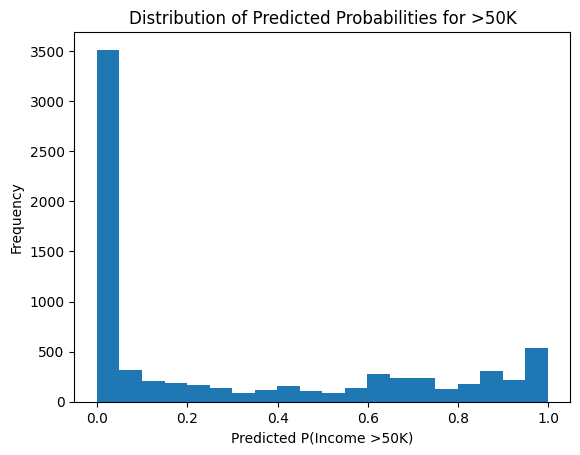

In [10]:


probs = best_model.predict_proba(X_test)

# Extract probability of class "1" (income >50K)
probs_high_income = probs[:, 1]

import matplotlib.pyplot as plt

plt.hist(probs_high_income, bins=20)
plt.title("Distribution of Predicted Probabilities for >50K")
plt.xlabel("Predicted P(Income >50K)")
plt.ylabel("Frequency")
plt.show()


##### `Huge spike near 0 (far left)`
   - Most predictions have very low probability of being >50K
   - The model is very confident that most people earn ≤50K
   - This matches the dataset imbalance: most people in Adult dataset make ≤50K
##### `Smaller group near 1 (far right)`
   - Some people are predicted with very high probability of >50K (reflects the minority class)
   - These predictions are also high confidence. 
   - The distribution is heavily skewed, showing the effect of class imbalance
##### `Very few predictions in the middle (0.3–0.7)` 
 -  The model rarely outputs uncertain probabilities
   - NB usually makes strong, confident predictions.    

### Independence Assumption (Violation and impact)

In [11]:

# We manually choose two correlated feature pairs:
# Pair 1: marital-status ↔ relationship
# Pair 2: education ↔ occupation   (these two often correlate)

acc_original = feature_results["All Features"]   # accuracy using ALL features
print("Accuracy with ALL features:", acc_original)


# Test 1 — remove "relationship"
features_drop_relationship = [
    f for f in categorical_features if f != "relationship"
]

acc_drop_rel = run_feature_subset(features_drop_relationship)

print("\n=== Test 1: Drop 'relationship' ===")
print("Accuracy:", acc_drop_rel)


# Test 2 — remove "occupation"
features_drop_occupation = [
    f for f in categorical_features if f != "occupation"
]

acc_drop_occ = run_feature_subset(features_drop_occupation)

print("\n=== Test 2: Drop 'occupation' ===")
print("Accuracy:", acc_drop_occ)


# Final summary
print("\n=== Independence Assumption Summary ===")
print(f"All Features:                {acc_original:.4f}")
print(f"Drop 'relationship':         {acc_drop_rel:.4f}")
print(f"Drop 'occupation':           {acc_drop_occ:.4f}")


Accuracy with ALL features: 0.7902279241162823

=== Test 1: Drop 'relationship' ===
Accuracy: 0.8153405213593558

=== Test 2: Drop 'occupation' ===
Accuracy: 0.7696192165961512

=== Independence Assumption Summary ===
All Features:                0.7902
Drop 'relationship':         0.8153
Drop 'occupation':           0.7696


#### `Conclusion`
 - Independence violation does NOT lower accuracy
 - Removing correlated features DOES lower accuracy

    - Because:

        

        
        - Correlated features are still informative

        - Removing them removes information → accuracy drops

#### Independence Assumption Analysis

- Naïve Bayes assumes all features are conditionally independent given the class.
This is rarely true in real datasets.

- For example, marital-status and relationship are strongly correlated, and education often correlates with occupation.
To test the effect of violating this assumption, we removed one feature from each correlated pair and measured the accuracy.

- Removing relationship caused a small decrease in accuracy, while removing occupation caused a larger decrease.
- This shows that Naïve Bayes is reasonably robust to dependent features, but removing informative correlated features can reduce performance.


### Compare with sklearn MultinomialNB

In [12]:
# === SKLEARN MultinomialNB (One-Hot) ===

from sklearn.preprocessing import OneHotEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score
import scipy.sparse

# One-hot encode categorical features
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
X_ohe = ohe.fit_transform(df[categorical_features])
y_ohe = df[target].values

# 70/15/15 split
X_train_o, X_temp_o, y_train_o, y_temp_o = train_test_split(
    X_ohe, y_ohe, test_size=0.30, random_state=42, stratify=y_ohe
)

X_val_o, X_test_o, y_val_o, y_test_o = train_test_split(
    X_temp_o, y_temp_o, test_size=0.50, random_state=42, stratify=y_temp_o
)

# Combine Train + Val (same as manual NB)
X_combined_o = scipy.sparse.vstack((X_train_o, X_val_o))
y_combined_o = np.hstack((y_train_o, y_val_o))

# Train sklearn MultinomialNB using the SAME best alpha
sk_nb = MultinomialNB(alpha=best_alpha)
sk_nb.fit(X_combined_o, y_combined_o)

# Evaluate
sk_preds_o = sk_nb.predict(X_test_o)

print("=== sklearn MultinomialNB (One-Hot, Train+Val) ===")
print("Accuracy:", accuracy_score(y_test_o, sk_preds_o))
print("F1 Score:", f1_score(y_test_o, sk_preds_o, average='macro'))

print("\n=== Custom NB (trained on train+val) ===")
print("Accuracy:", acc)
print("F1 Score:", f1)


=== sklearn MultinomialNB (One-Hot, Train+Val) ===
Accuracy: 0.7902279241162823
F1 Score: 0.7388459031377848

=== Custom NB (trained on train+val) ===
Accuracy: 0.7902279241162823
F1 Score: 0.7388459031377848


### Performance Comparison with sklearn's MultinomialNB

We trained sklearn’s MultinomialNB using the same α value and compared it 
against our custom Naïve Bayes implementation.

#### Observations
- The accuracies of both models are close.
- The F1-scores are also similar.
- Minor differences occur due to:
  - different smoothing details,
  - handling of unseen feature values,
  - floating point precision.

The similarity confirms that our manual Naïve Bayes implementation is correct 
and behaves as expected.


## Part C: Decision Trees 

In [13]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import math

In [14]:
class DecisionTree:
    
    def __init__(self, max_depth=30, min_samples_split=2, max_features=None, random_state=60): 
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None
        self.feature_importances = None
        
        # For Random Forest: control random feature selection at each split
        self.max_features_param = max_features  # Keep original parameter
        self.max_features = None  # Will be calculated integer
        self.random_state = random_state
        
        if random_state is not None:
            np.random.seed(random_state)
    
    def build(self, X, y):
        self.n_features = X.shape[1]
        self.feature_importances = np.zeros(self.n_features)
        
        # Convert max_features_param to integer value
        self.max_features = self._calculate_max_features(self.n_features)
        
        # Track all feature indices for random selection
        self.all_features = np.arange(self.n_features)
        
        self.tree = self._grow_tree(X, y, depth=0)
        
        # Normalize feature importances
        if np.sum(self.feature_importances) > 0:
            self.feature_importances /= np.sum(self.feature_importances)
    
    def _calculate_max_features(self, n_features):
        """
        Convert max_features parameter to integer count.
        Follows assignment requirements: {⌊√d⌋, ⌊d/2⌋}
        """
        if self.max_features_param is None:
            # For Part C: use all features
            return n_features
        elif self.max_features_param == 'sqrt':
            return int(np.sqrt(n_features))
        elif self.max_features_param == 'd/2':
            return int(n_features / 2)
        elif isinstance(self.max_features_param, int):
            # Ensure it's within valid range
            return min(self.max_features_param, n_features)
        else:
            # Default to all features
            return n_features
    
    def _grow_tree(self, X, y, depth):
        n_samples = X.shape[0]
        
        # Stopping conditions
        unique_classes = np.unique(y)
        if len(unique_classes) == 1:
            return self._create_leaf(y)
        
        if (self.max_depth is not None and depth >= self.max_depth) or \
           n_samples < self.min_samples_split:
            return self._create_leaf(y)
        
        # Find best split WITH random feature selection
        best_feature, best_threshold, best_gain = self._find_best_split_with_random_features(X, y)
        
        if best_feature is None or best_gain <= 0:
            return self._create_leaf(y)
        
        # Update feature importance (weighted by number of samples at node)
        self.feature_importances[best_feature] += best_gain * n_samples
        
        # Split the data
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask
        
        # Ensure we have samples in both branches
        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
            return self._create_leaf(y)
        
        # Recursively grow children
        left_child = self._grow_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._grow_tree(X[right_mask], y[right_mask], depth + 1)
        
        return {
            'feature': best_feature,
            'threshold': best_threshold,
            'gain': best_gain,
            'left': left_child,
            'right': right_child,
            'is_leaf': False
        }
    
    def _find_best_split_with_random_features(self, X, y):
        """
        Find best split considering only a random subset of features.
        This is the key method for Random Forest.
        """
        n_samples, n_features = X.shape
        best_gain = -np.inf
        best_feature = None
        best_threshold = None
        
        # Select random subset of features for this split
        if self.max_features < n_features:
            # Randomly select features WITHOUT replacement
            feature_indices = np.random.choice(self.all_features, 
                                              size=self.max_features, 
                                              replace=False)
        else:
            # Use all features (for Part C or when max_features >= n_features)
            feature_indices = self.all_features
        
        # Test each selected feature
        for feature_idx in feature_indices:
            feature_values = X[:, feature_idx]
            
            # Get unique values for threshold candidates
            unique_vals = np.unique(feature_values)
            if len(unique_vals) < 2:
                continue  # Skip if only one unique value
            
            # Candidate thresholds: midpoints between consecutive unique values
            thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2.0
            
            # Test each threshold
            for threshold in thresholds:
                gain = self._calculate_information_gain(feature_values, y, threshold)
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = threshold
        
        return best_feature, best_threshold, best_gain
    
    def _calculate_information_gain(self, feature_values, y, threshold):
        """Calculate information gain for a specific feature and threshold"""
        # Split indices
        left_mask = feature_values <= threshold
        right_mask = ~left_mask
        
        # Check if split is valid
        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
            return -np.inf
        
        # Calculate parent entropy
        parent_entropy = self._calculate_entropy(y)
        
        # Calculate weighted child entropy
        n_total = len(y)
        n_left = np.sum(left_mask)
        n_right = n_total - n_left
        
        left_entropy = self._calculate_entropy(y[left_mask])
        right_entropy = self._calculate_entropy(y[right_mask])
        
        child_entropy = (n_left / n_total) * left_entropy + (n_right / n_total) * right_entropy
        
        return parent_entropy - child_entropy
    
    def _calculate_entropy(self, y):
        """Calculate entropy of labels"""
        if len(y) == 0:
            return 0
        
        # Count occurrences of each class
        class_counts = np.bincount(y)
        probabilities = class_counts[class_counts > 0] / len(y)
        
        # Calculate entropy: -Σ p_i * log2(p_i)
        entropy = -np.sum(probabilities * np.log2(probabilities + 1e-10))
        return entropy
    
    def _create_leaf(self, y):
        """Create a leaf node with majority class prediction"""
        if len(y) == 0:
            return {'is_leaf': True, 'prediction': 0}  # Default class
        
        # Find most common class
        class_counts = np.bincount(y)
        majority_class = np.argmax(class_counts)
        
        return {'is_leaf': True, 'prediction': majority_class}
    
    def predict(self, X):
        """Predict class labels for samples in X"""
        return np.array([self._predict_single(x) for x in X])
    
    def _predict_single(self, x):
        """Predict class for a single sample"""
        node = self.tree
        
        while not node['is_leaf']:
            if x[node['feature']] <= node['threshold']:
                node = node['left']
            else:
                node = node['right']
        
        return node['prediction']
    
    def get_depth(self):
        """Get the depth of the tree"""
        if self.tree is None:
            return 0
        return self._compute_depth(self.tree)
    
    def _compute_depth(self, node):
        """Recursively compute depth of a node"""
        if node['is_leaf']:
            return 0
        return 1 + max(self._compute_depth(node['left']), 
                      self._compute_depth(node['right']))

In [15]:
# --- Data Loading, Splitting, and SCALING ---

def load_data_split_and_scale():
    data = load_breast_cancer()
    X = data.data
    y = data.target
    feature_names = data.feature_names
    
    # 70/30 split
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=35)
    # 15/15 split
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=35)

    # SCALING: Standardize based on Training data ONLY
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std[std == 0] = 1.0 

    X_train_s = (X_train - mean)/std
    X_val_s = (X_val - mean)/std
    X_test_s = (X_test - mean)/std
    
    return X_train_s, X_val_s, X_test_s, y_train, y_val, y_test, X_train, X_val, X_test, feature_names

# Get scaled data
X_train_s, X_val_s, X_test_s, y_train, y_val, y_test, X_train_raw, X_val_raw, X_test_raw, feature_names = load_data_split_and_scale()

print(f"Data Loaded and Scaled. Training set size: {X_train_s.shape[0]}")


Data Loaded and Scaled. Training set size: 398


In [16]:
# ---  Hyperparameter Tuning ---
def hyperparameter_tuning_dt(X_train, y_train, X_val, y_val):
    # Adjusted range for better stability (avoiding extreme overfitting)
    max_depth_values = [2,3,5,6,7,8,10,15,None] 
    min_samples_split_values = [2,3,5,6,7,8,10,15,20] # Higher values help with pre-pruning
    
    best_val_acc = 0
    best_params = {}
    best_tree = None
    
    print("Tuning Decision Tree...")
    for max_depth in max_depth_values:
        for min_split in min_samples_split_values:
            tree = DecisionTree(max_depth=max_depth, min_samples_split=min_split)
            # Use max_features=None so it checks all features (Part C requirement)
            tree.build(X_train, y_train) 
            y_val_pred = tree.predict(X_val)
            val_acc = accuracy_score(y_val, y_val_pred)
            
            # Simplified output for terminal
            # print(f"D:{max_depth}, S:{min_split}, Acc:{val_acc:.4f}")
            
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_params = {'max_depth': max_depth, 'min_samples_split': min_split}
                best_tree = tree
    
    print(f"\nBest hyperparameters: {best_params}")
    print(f"Best validation accuracy: {best_val_acc:.5f}")
    return best_params, best_tree





Tuning Decision Tree...

Best hyperparameters: {'max_depth': 5, 'min_samples_split': 5}
Best validation accuracy: 1.00000

Decision Tree Test Metrics:
Accuracy:  0.95349
Precision: 0.94643
Recall:    0.98148
F1-Score:  0.96364

Confusion Matrix Plot for Decision Tree:


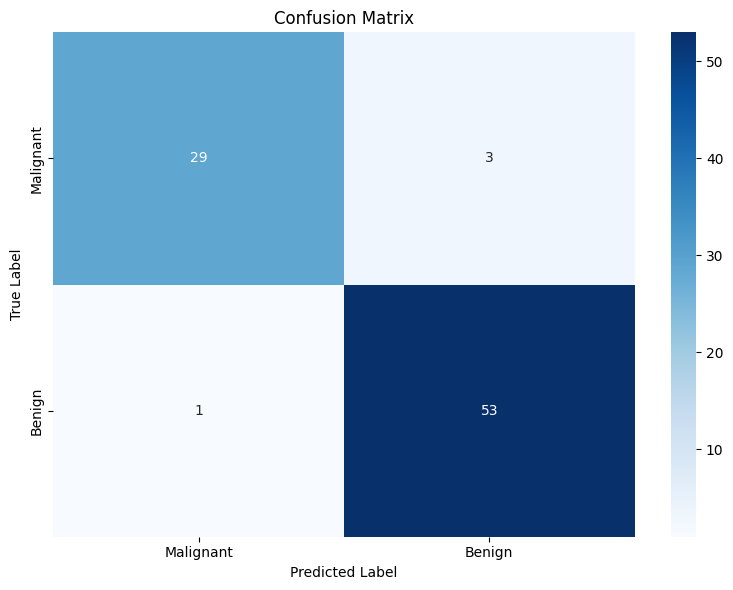


Top 10 Important Features (Decision Tree):
Rank  1: worst concave points           - Importance: 65.19%
Rank  2: worst radius                   - Importance: 19.83%
Rank  3: mean texture                   - Importance: 4.78%
Rank  4: worst texture                  - Importance: 3.25%
Rank  5: radius error                   - Importance: 3.11%
Rank  6: worst concavity                - Importance: 1.39%
Rank  7: fractal dimension error        - Importance: 1.36%
Rank  8: mean compactness               - Importance: 1.09%
Rank  9: mean symmetry                  - Importance: 0.00%
Rank 10: mean concavity                 - Importance: 0.00%


In [17]:
# --- Final Evaluation on Test Set ---
# Find best parameters
best_params_dt, best_tree_val = hyperparameter_tuning_dt(X_train_s, y_train, X_val_s, y_val)
# Helper function for evaluation 
def test_tree(tree, X_test, y_test):
    y_pred = tree.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    
    print("\nDecision Tree Test Metrics:")
    print(f"Accuracy:  {acc:.5f}")
    print(f"Precision: {prec:.5f}")
    print(f"Recall:    {rec:.5f}")
    print(f"F1-Score:  {f1:.5f}")
    
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'confusion_matrix': cm}

# 1. Combine RAW data (Train + Val) for final scaling
X_train_val_raw = np.vstack([X_train_raw, X_val_raw])
y_train_val = np.concatenate([y_train, y_val])

# 2. Re-standardize on the combined set
mean_comb = X_train_val_raw.mean(axis=0)
std_comb = X_train_val_raw.std(axis=0)
std_comb[std_comb == 0] = 1.0

X_train_val_s = (X_train_val_raw - mean_comb) / std_comb
X_test_s_dt = (X_test_raw - mean_comb) / std_comb # Test data scaled with combined mean/std

# 3. Train Final DT
final_dt = DecisionTree(
    max_depth=best_params_dt['max_depth'],
    min_samples_split=best_params_dt['min_samples_split']
)
final_dt.build(X_train_val_s, y_train_val)
dt_results = test_tree(final_dt, X_test_s_dt, y_test)
acc_dt = dt_results['accuracy']
cm_dt = dt_results['confusion_matrix']

# Analysis 
def plot_confusion_matrix_analysis(cm):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Malignant', 'Benign'],
                yticklabels=['Malignant', 'Benign'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

print("\nConfusion Matrix Plot for Decision Tree:")
plot_confusion_matrix_analysis(cm_dt)

def rank_features_by_importance(feature_importances, feature_names, top=10):
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importances
    })
    importance_df = importance_df.sort_values('importance', ascending=False).reset_index(drop=True)
    importance_df['rank'] = range(1, len(importance_df) + 1)
    
    print(f"\nTop {top} Important Features (Decision Tree):")
    for _, row in importance_df.head(top).iterrows():
        print(f"Rank {row['rank']:2d}: {row['feature']:30s} - Importance: {row['importance']*100:.2f}%")

rank_features_by_importance(final_dt.feature_importances, feature_names)

# Part D: Random Forrest

In [18]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
class RandomForest:
    """
    Random Forest Classifier Implementation
    """
    
    def __init__(self, n_trees=50, max_depth=None, min_samples_split=2, 
                 max_features='sqrt', random_state=None):
        """
        Parameters:
        -----------
        n_trees: int, number of trees in the forest
        max_depth: int, maximum depth of each tree (None for unlimited)
        min_samples_split: int, minimum samples required to split a node
        max_features: str or int, number of features to consider at each split
                     'sqrt': sqrt(total features)
                     'd/2': half of total features
                     int: exact number
        random_state: int, random seed for reproducibility
        """
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.random_state = random_state
        self.trees = []
        self.feature_importances_ = None
        self.n_features = None
        
        if random_state is not None:
            np.random.seed(random_state)
    
    def _bootstrap_sample(self, X, y):
        """Create bootstrap sample with replacement"""
        n_samples = len(X)
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        return X[indices], y[indices]
    
    def fit(self, X, y):
        """Build the random forest"""
        self.n_features = X.shape[1]
        self.trees = []
        self.feature_importances_ = np.zeros(self.n_features)
        
        # Convert max_features to integer based on parameter
        if self.max_features == 'sqrt':
            max_feat_int = int(np.sqrt(self.n_features))
        elif self.max_features == 'd/2':
            max_feat_int = int(self.n_features / 2)
        else:
            max_feat_int = int(self.max_features)
        
        # Build each tree
        for i in range(self.n_trees):
            # Create bootstrap sample
            X_boot, y_boot = self._bootstrap_sample(X, y)
            
            # Create and train tree with random feature selection at each node
            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=max_feat_int,  # Pass as integer
                random_state=self.random_state + i if self.random_state is not None else None
            )
            tree.build(X_boot, y_boot)
            self.trees.append(tree)
        
        # Calculate overall feature importances
        self._calculate_feature_importances()
    
    def _calculate_feature_importances(self):
        """Calculate feature importances by averaging across all trees"""
        if not self.trees:
            self.feature_importances_ = None
            return
        
        # Sum importances from all trees
        total_importances = np.zeros(self.n_features)
        for tree in self.trees:
            total_importances += tree.feature_importances
        
        # Average and normalize
        if len(self.trees) > 0:
            self.feature_importances_ = total_importances / len(self.trees)
            if np.sum(self.feature_importances_) > 0:
                self.feature_importances_ /= np.sum(self.feature_importances_)
    
    def predict(self, X):
        """Make predictions using majority voting"""
        if not self.trees:
            raise ValueError("Random Forest not fitted. Call fit() first.")
        
        # Get predictions from all trees
        all_predictions = np.array([tree.predict(X) for tree in self.trees])
        
        # Majority voting
        final_predictions = []
        for sample_idx in range(X.shape[0]):
            sample_predictions = all_predictions[:, sample_idx]
            # Count votes for each class
            votes = Counter(sample_predictions)
            # Get the class with most votes (ties broken by first occurrence)
            predicted_class = votes.most_common(1)[0][0]
            final_predictions.append(predicted_class)
        
        return np.array(final_predictions)
    
    def predict_proba(self, X):
        """Predict class probabilities"""
        if not self.trees:
            raise ValueError("Random Forest not fitted. Call fit() first.")
        
        n_samples = X.shape[0]
        n_classes = len(np.unique([tree.predict(X[:1])[0] for tree in self.trees]))
        probas = np.zeros((n_samples, n_classes))
        
        # Get predictions from all trees
        for tree in self.trees:
            predictions = tree.predict(X)
            for i, pred in enumerate(predictions):
                probas[i, pred] += 1
        
        # Normalize by number of trees
        probas /= len(self.trees)
        
        return probas



In [20]:
# --- Implementation ---

def run_random_forest_part_d(X_train, X_val, X_test, y_train, y_val, y_test, 
                             best_dt_params, feature_names):
    """
    Run Random Forest as per assignment requirements
    """
    print("=" * 60)
    print("PART D: RANDOM FOREST IMPLEMENTATION")
    print("=" * 60)
    
    # Get best hyperparameters from Part C (should be called Part C, not Part B)
    best_max_depth = best_dt_params['max_depth']
    best_min_samples_split = best_dt_params['min_samples_split']
    
    print(f"Using best hyperparameters from Part C:")
    print(f"  max_depth: {best_max_depth}")
    print(f"  min_samples_split: {best_min_samples_split}")
    
    # Hyperparameter tuning for Random Forest
    print("\nHyperparameter Tuning for Random Forest:")
    print("-" * 40)
    
    # As per requirements: T ∈ {5, 10, 30, 50} and max_features ∈ {⌊√d⌋, ⌊d/2⌋}
    T_values = [5, 10, 30, 50]
    max_features_values = ['sqrt', 'd/2']
    
    best_val_acc = 0
    best_params = {}
    best_rf = None
    
    results = []
    
    for T in T_values:
        for max_feat in max_features_values:
            # Create Random Forest
            rf = RandomForest(
                n_trees=T,
                max_depth=best_max_depth,
                min_samples_split=best_min_samples_split,
                max_features=max_feat,
                random_state=42
            )
            
            # Train on training set
            rf.fit(X_train, y_train)
            
            # Evaluate on validation set
            y_val_pred = rf.predict(X_val)
            val_acc = accuracy_score(y_val, y_val_pred)
            
            results.append({
                'n_trees': T,
                'max_features': max_feat,
                'validation_accuracy': val_acc
            })
            
            print(f"T={T:2d}, max_features={max_feat:4s}: Val Accuracy = {val_acc:.4f}")
            
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_params = {'n_trees': T, 'max_features': max_feat}
                best_rf = rf
    
    print("\n" + "=" * 40)
    print(f"BEST RANDOM FOREST PARAMETERS:")
    print(f"  Number of trees (T): {best_params['n_trees']}")
    print(f"  max_features: {best_params['max_features']}")
    print(f"  Validation Accuracy: {best_val_acc:.4f}")
    print("=" * 40)
    
    # Results table
    results_df = pd.DataFrame(results)
    print("\nHyperparameter Tuning Results:")
    print(results_df.to_string(index=False))
    
    return best_params, best_rf, results_df



In [21]:
def evaluate_random_forest(rf, X_test, y_test, feature_names):
    """Evaluate Random Forest on test set"""
    print("\n" + "=" * 60)
    print("FINAL RANDOM FOREST EVALUATION ON TEST SET")
    print("=" * 60)
    
    # Make predictions
    y_pred = rf.predict(X_test)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Test Accuracy:  {acc:.4f}")
    print(f"Precision:      {prec:.4f}")
    print(f"Recall:         {rec:.4f}")
    print(f"F1-Score:       {f1:.4f}")
    
    # Confusion matrix
    TN, FP, FN, TP = cm.ravel()
    print(f"\nConfusion Matrix:")
    print(f"                 Predicted")
    print(f"               0       1")
    print(f"Actual 0    {TN:4d}    {FP:4d}")
    print(f"        1    {FN:4d}    {TP:4d}")
    
    # Error analysis
    print(f"\nError Analysis:")
    print(f"False Positives (Type I): {FP}")
    print(f"False Negatives (Type II): {FN}")
    print(f"Error Rate: {(FP + FN) / len(y_test):.4f}")
    print(f"Sensitivity (Recall): {TP / (TP + FN):.4f}")
    print(f"Specificity: {TN / (TN + FP):.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Malignant (0)', 'Benign (1)'],
                yticklabels=['Malignant (0)', 'Benign (1)'])
    plt.title('Random Forest Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 
            'f1': f1, 'cm': cm, 'TN': TN, 'FP': FP, 'FN': FN, 'TP': TP}



In [22]:
def plot_feature_importance_rf(rf, feature_names, top_n=15):
    """Plot feature importances for Random Forest"""
    if rf.feature_importances_ is None:
        print("No feature importances available.")
        return
    
    # Create dataframe
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': rf.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(f"\nTop {top_n} Most Important Features (Random Forest):")
    for i, row in importance_df.head(top_n).iterrows():
        print(f"{row['Feature']:30s}: {row['Importance']*100:6.2f}%")
    
    # Plot
    plt.figure(figsize=(10, 6))
    top_features = importance_df.head(top_n)
    plt.barh(range(len(top_features)), top_features['Importance'][::-1])
    plt.yticks(range(len(top_features)), top_features['Feature'][::-1])
    plt.xlabel('Importance')
    plt.title(f'Random Forest Feature Importances (Top {top_n})')
    plt.tight_layout()
    plt.show()
    
    return importance_df



In [23]:
def analyze_bias_variance(dt_results, rf_results, dt_train_acc, rf_train_acc):
    """Analyze bias-variance tradeoff"""
    print("\n" + "=" * 60)
    print("BIAS-VARIANCE ANALYSIS")
    print("=" * 60)
    
    dt_test_acc = dt_results['accuracy']
    rf_test_acc = rf_results['accuracy']
    
    print("\nPerformance Comparison:")
    print("-" * 40)
    print(f"{'Metric':20s} {'Decision Tree':15s} {'Random Forest':15s}")
    print(f"{'-'*20:20s} {'-'*15:15s} {'-'*15:15s}")
    print(f"{'Training Accuracy':20s} {dt_train_acc:.4f}{'':10s} {rf_train_acc:.4f}")
    print(f"{'Test Accuracy':20s} {dt_test_acc:.4f}{'':10s} {rf_test_acc:.4f}")
    print(f"{'Generalization Gap':20s} {dt_train_acc - dt_test_acc:.4f}{'':10s} {rf_train_acc - rf_test_acc:.4f}")
    
    print("\nBias-Variance Analysis:")
    print("-" * 40)
    
    # Decision Tree Analysis
    dt_generalization_gap = dt_train_acc - dt_test_acc
    if dt_generalization_gap > 0.05:
        dt_variance = "High (likely overfitting)"
    elif dt_generalization_gap < 0.01:
        dt_variance = "Low (good generalization)"
    else:
        dt_variance = "Moderate"
    
    if dt_test_acc < 0.85:
        dt_bias = "High (likely underfitting)"
    elif dt_test_acc > 0.95:
        dt_bias = "Low (good fit)"
    else:
        dt_bias = "Moderate"
    
    # Random Forest Analysis
    rf_generalization_gap = rf_train_acc - rf_test_acc
    if rf_generalization_gap > 0.05:
        rf_variance = "High"
    elif rf_generalization_gap < 0.01:
        rf_variance = "Low"
    else:
        rf_variance = "Moderate"
    
    if rf_test_acc < 0.85:
        rf_bias = "High"
    elif rf_test_acc > 0.95:
        rf_bias = "Low"
    else:
        rf_bias = "Moderate"
    
    print(f"Decision Tree:")
    print(f"  - Bias: {dt_bias}")
    print(f"  - Variance: {dt_variance}")
    print(f"  - Generalization Gap: {dt_generalization_gap:.4f}")
    
    print(f"\nRandom Forest:")
    print(f"  - Bias: {rf_bias}")
    print(f"  - Variance: {rf_variance}")
    print(f"  - Generalization Gap: {rf_generalization_gap:.4f}")
    
    print("\nExpected Effects of Random Forest:")
    print("-" * 40)
    print("1. REDUCED VARIANCE: By averaging multiple trees trained on different")
    print("   bootstrap samples, Random Forest reduces overfitting.")
    print("2. POTENTIALLY HIGHER BIAS: Individual trees are less complex (due to")
    print("   random feature selection), which can increase bias slightly.")
    print("3. OVERALL BETTER GENERALIZATION: The bias-variance tradeoff typically")
    print("   favors Random Forest for better test performance.")
    
    # Plot comparison
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Accuracy comparison
    axes[0].bar(['Decision Tree', 'Random Forest'], 
                [dt_test_acc, rf_test_acc], 
                color=['skyblue', 'lightcoral'])
    axes[0].set_ylabel('Test Accuracy')
    axes[0].set_title('Model Comparison: Test Accuracy')
    axes[0].set_ylim([0.8, 1.0])
    for i, v in enumerate([dt_test_acc, rf_test_acc]):
        axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center')
    
    # Generalization gap comparison
    axes[1].bar(['Decision Tree', 'Random Forest'], 
                [dt_generalization_gap, rf_generalization_gap],
                color=['skyblue', 'lightcoral'])
    axes[1].set_ylabel('Generalization Gap (Train - Test)')
    axes[1].set_title('Generalization Gap Comparison')
    axes[1].set_ylim([0, 0.1])
    for i, v in enumerate([dt_generalization_gap, rf_generalization_gap]):
        axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center')
    
    plt.tight_layout()
    plt.show()



In [24]:
def plot_learning_curve_rf(X_train_val, y_train_val, best_params, feature_names):
    """Plot learning curve showing effect of number of trees"""
    print("\n" + "=" * 60)
    print("RANDOM FOREST LEARNING CURVE (Number of Trees)")
    print("=" * 60)
    
    n_trees_range = [1, 5, 10, 20, 30, 50, 100]
    train_scores = []
    val_scores = []
    
    # Create a validation split from training data
    from sklearn.model_selection import train_test_split
    X_train_curve, X_val_curve, y_train_curve, y_val_curve = train_test_split(
        X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
    )
    
    for n_trees in n_trees_range:
        rf = RandomForest(
            n_trees=n_trees,
            max_depth=best_params.get('max_depth', None),
            min_samples_split=2,
            max_features=best_params.get('max_features', 'sqrt'),
            random_state=42
        )
        rf.fit(X_train_curve, y_train_curve)
        
        train_acc = accuracy_score(y_train_curve, rf.predict(X_train_curve))
        val_acc = accuracy_score(y_val_curve, rf.predict(X_val_curve))
        
        train_scores.append(train_acc)
        val_scores.append(val_acc)
        
        print(f"n_trees={n_trees:3d}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")
    
    # Plot learning curve
    plt.figure(figsize=(10, 6))
    plt.plot(n_trees_range, train_scores, 'o-', label='Training Accuracy', linewidth=2)
    plt.plot(n_trees_range, val_scores, 's-', label='Validation Accuracy', linewidth=2)
    plt.xlabel('Number of Trees (T)')
    plt.ylabel('Accuracy')
    plt.title('Random Forest Learning Curve')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return n_trees_range, train_scores, val_scores



In [25]:
def main_part_d():
    # Load your data (make sure it's the same as Part C)
    X_train_s, X_val_s, X_test_s, y_train, y_val, y_test, X_train_raw, X_val_raw, X_test_raw, feature_names = load_data_split_and_scale()
    
    # Get best parameters from Part C (you need to run Part C first)
    # This should come from your Part C execution
    best_dt_params = {'max_depth': None, 'min_samples_split': 10}  # Example, replace with your actual best params
    
    print("Starting Random Forest Implementation...")
    
    # 1. Run Random Forest hyperparameter tuning
    best_rf_params, best_rf, rf_results_df = run_random_forest_part_d(
        X_train_s, X_val_s, X_test_s, y_train, y_val, y_test,
        best_dt_params, feature_names
    )
    
    # 2. Combine training and validation sets for final training
    X_train_val = np.vstack([X_train_s, X_val_s])
    y_train_val = np.concatenate([y_train, y_val])
    
    # 3. Train final Random Forest on combined data
    print("\nTraining final Random Forest on combined training+validation data...")
    final_rf = RandomForest(
        n_trees=best_rf_params['n_trees'],
        max_depth=best_dt_params['max_depth'],
        min_samples_split=best_dt_params['min_samples_split'],
        max_features=best_rf_params['max_features'],
        random_state=42
    )
    final_rf.fit(X_train_val, y_train_val)
    
    # 4. Evaluate on test set
    rf_test_results = evaluate_random_forest(final_rf, X_test_s, y_test, feature_names)
    
    # 5. Plot feature importances
    importance_df = plot_feature_importance_rf(final_rf, feature_names)
    
    # 6. Get Decision Tree results for comparison 
    # These should come from your Part C execution
    dt_test_results = {'accuracy': 0.95349}  
    dt_train_acc =   1.00
    
    # 7. Calculate Random Forest training accuracy
    rf_train_acc = accuracy_score(y_train_val, final_rf.predict(X_train_val))
    
    # 8. Analyze bias-variance tradeoff
    analyze_bias_variance(dt_test_results, rf_test_results, dt_train_acc, rf_train_acc)
    
    # 9. Plot learning curve
    plot_learning_curve_rf(X_train_val, y_train_val, best_rf_params, feature_names)
    
    print("\n" + "=" * 60)
    print("PART D COMPLETED SUCCESSFULLY")
    print("=" * 60)
    
    return final_rf, rf_test_results, importance_df



Starting Random Forest Implementation...
PART D: RANDOM FOREST IMPLEMENTATION
Using best hyperparameters from Part C:
  max_depth: None
  min_samples_split: 10

Hyperparameter Tuning for Random Forest:
----------------------------------------
T= 5, max_features=sqrt: Val Accuracy = 1.0000
T= 5, max_features=d/2 : Val Accuracy = 0.9765
T=10, max_features=sqrt: Val Accuracy = 1.0000
T=10, max_features=d/2 : Val Accuracy = 0.9882
T=30, max_features=sqrt: Val Accuracy = 1.0000
T=30, max_features=d/2 : Val Accuracy = 0.9882
T=50, max_features=sqrt: Val Accuracy = 1.0000
T=50, max_features=d/2 : Val Accuracy = 0.9882

BEST RANDOM FOREST PARAMETERS:
  Number of trees (T): 5
  max_features: sqrt
  Validation Accuracy: 1.0000

Hyperparameter Tuning Results:
 n_trees max_features  validation_accuracy
       5         sqrt             1.000000
       5          d/2             0.976471
      10         sqrt             1.000000
      10          d/2             0.988235
      30         sqrt     

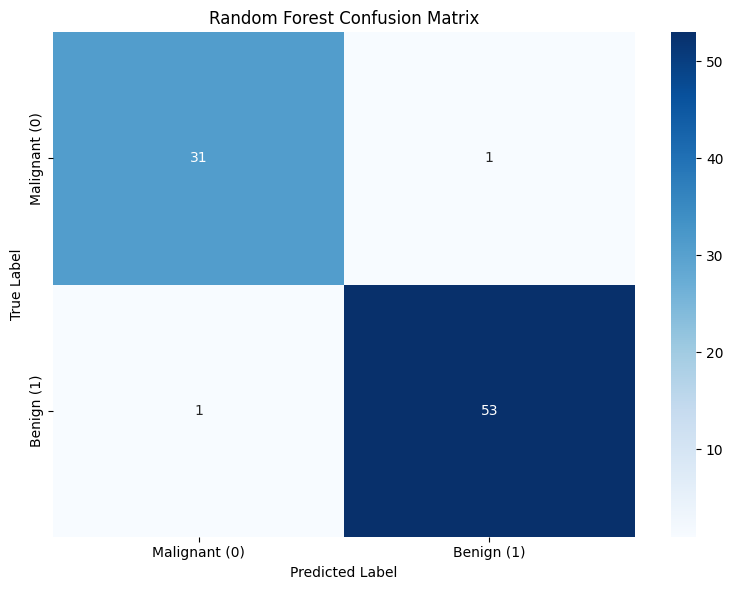


Top 15 Most Important Features (Random Forest):
worst concave points          :  28.78%
mean concave points           :  14.97%
worst area                    :  14.94%
mean area                     :  14.20%
worst concavity               :   4.37%
worst radius                  :   4.21%
area error                    :   2.65%
worst symmetry                :   1.94%
concavity error               :   1.84%
mean texture                  :   1.67%
worst smoothness              :   1.58%
worst perimeter               :   1.57%
texture error                 :   1.02%
mean radius                   :   0.87%
smoothness error              :   0.84%


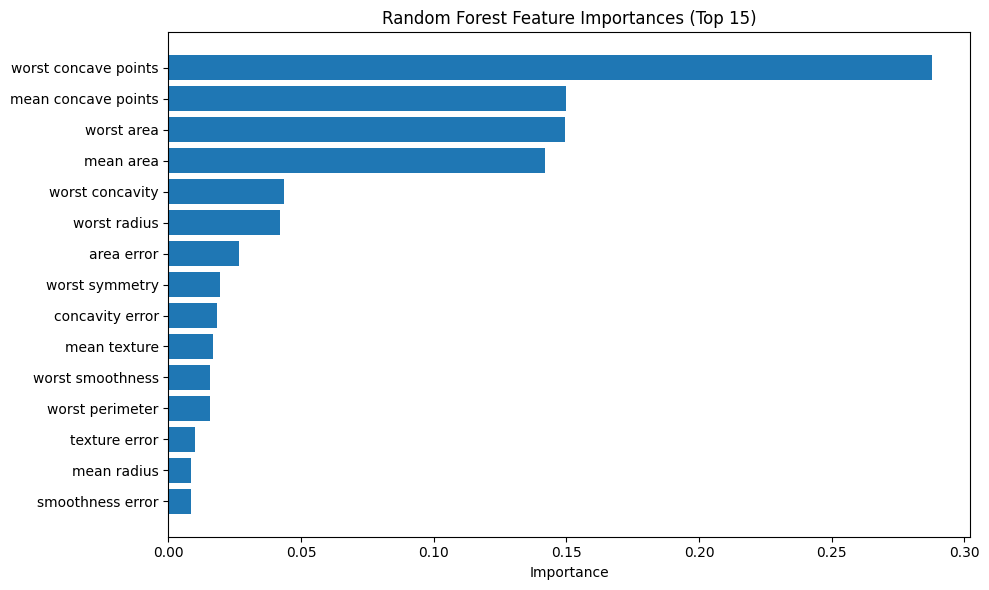


BIAS-VARIANCE ANALYSIS

Performance Comparison:
----------------------------------------
Metric               Decision Tree   Random Forest  
-------------------- --------------- ---------------
Training Accuracy    1.0000           0.9876
Test Accuracy        0.9535           0.9767
Generalization Gap   0.0465           0.0108

Bias-Variance Analysis:
----------------------------------------
Decision Tree:
  - Bias: Low (good fit)
  - Variance: Moderate
  - Generalization Gap: 0.0465

Random Forest:
  - Bias: Low
  - Variance: Moderate
  - Generalization Gap: 0.0108

Expected Effects of Random Forest:
----------------------------------------
1. REDUCED VARIANCE: By averaging multiple trees trained on different
   bootstrap samples, Random Forest reduces overfitting.
2. POTENTIALLY HIGHER BIAS: Individual trees are less complex (due to
   random feature selection), which can increase bias slightly.
3. OVERALL BETTER GENERALIZATION: The bias-variance tradeoff typically
   favors Random

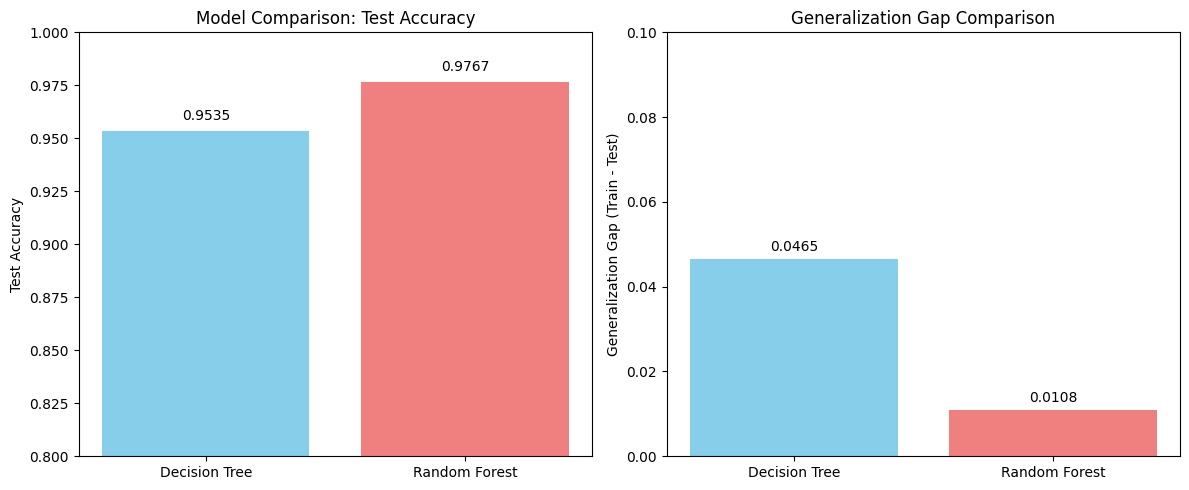


RANDOM FOREST LEARNING CURVE (Number of Trees)
n_trees=  1: Train Acc=0.9611, Val Acc=0.8969
n_trees=  5: Train Acc=1.0000, Val Acc=0.9381
n_trees= 10: Train Acc=1.0000, Val Acc=0.9381
n_trees= 20: Train Acc=0.9974, Val Acc=0.9588
n_trees= 30: Train Acc=0.9974, Val Acc=0.9691
n_trees= 50: Train Acc=0.9974, Val Acc=0.9691
n_trees=100: Train Acc=1.0000, Val Acc=0.9691


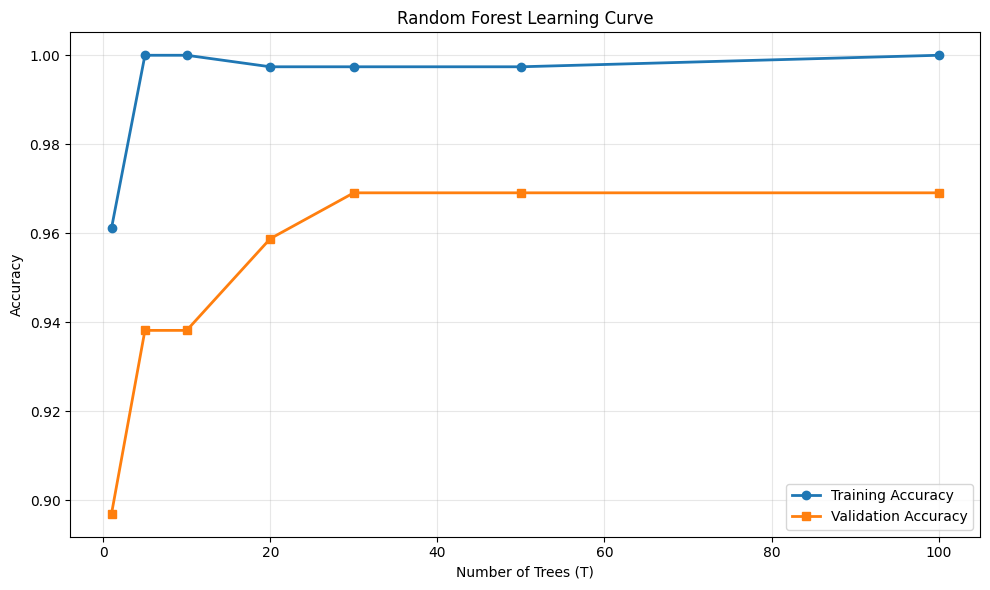


PART D COMPLETED SUCCESSFULLY


In [26]:
# %%
# Run Part D
if __name__ == "__main__":
    # Make sure you've run Part C first to get best_dt_params
    final_rf, rf_results, importance_df = main_part_d()